In [1]:
import pygmt
import pandas as pd
import h5py
import numpy as np

In [2]:
with h5py.File('OUTPUT_FILES/initial_model.h5', 'r') as f:
    print(f.keys())
    vsi = f['vs'][:]
    vpi = f['vp'][:]
    rho = f['rho'][:]
    x = f['x'][:]
    y = f['y'][:]
    z = f['z'][:]
with h5py.File('OUTPUT_FILES/final_model.h5', 'r') as f:
    vsf = f['vs'][:]
    vpf = f['vp'][:]
    rhof = f['rho'][:]


dvs = (vsf - vsi) / vsi * 100
dvp = (vpf - vpi) / vpi * 100
drho = (rhof - rho) / rho * 100
vmax = 8.0

<KeysViewHDF5 ['rho', 'vp', 'vs', 'x', 'y', 'z']>


Plotting depth slice at z=3.50 km (index 7)


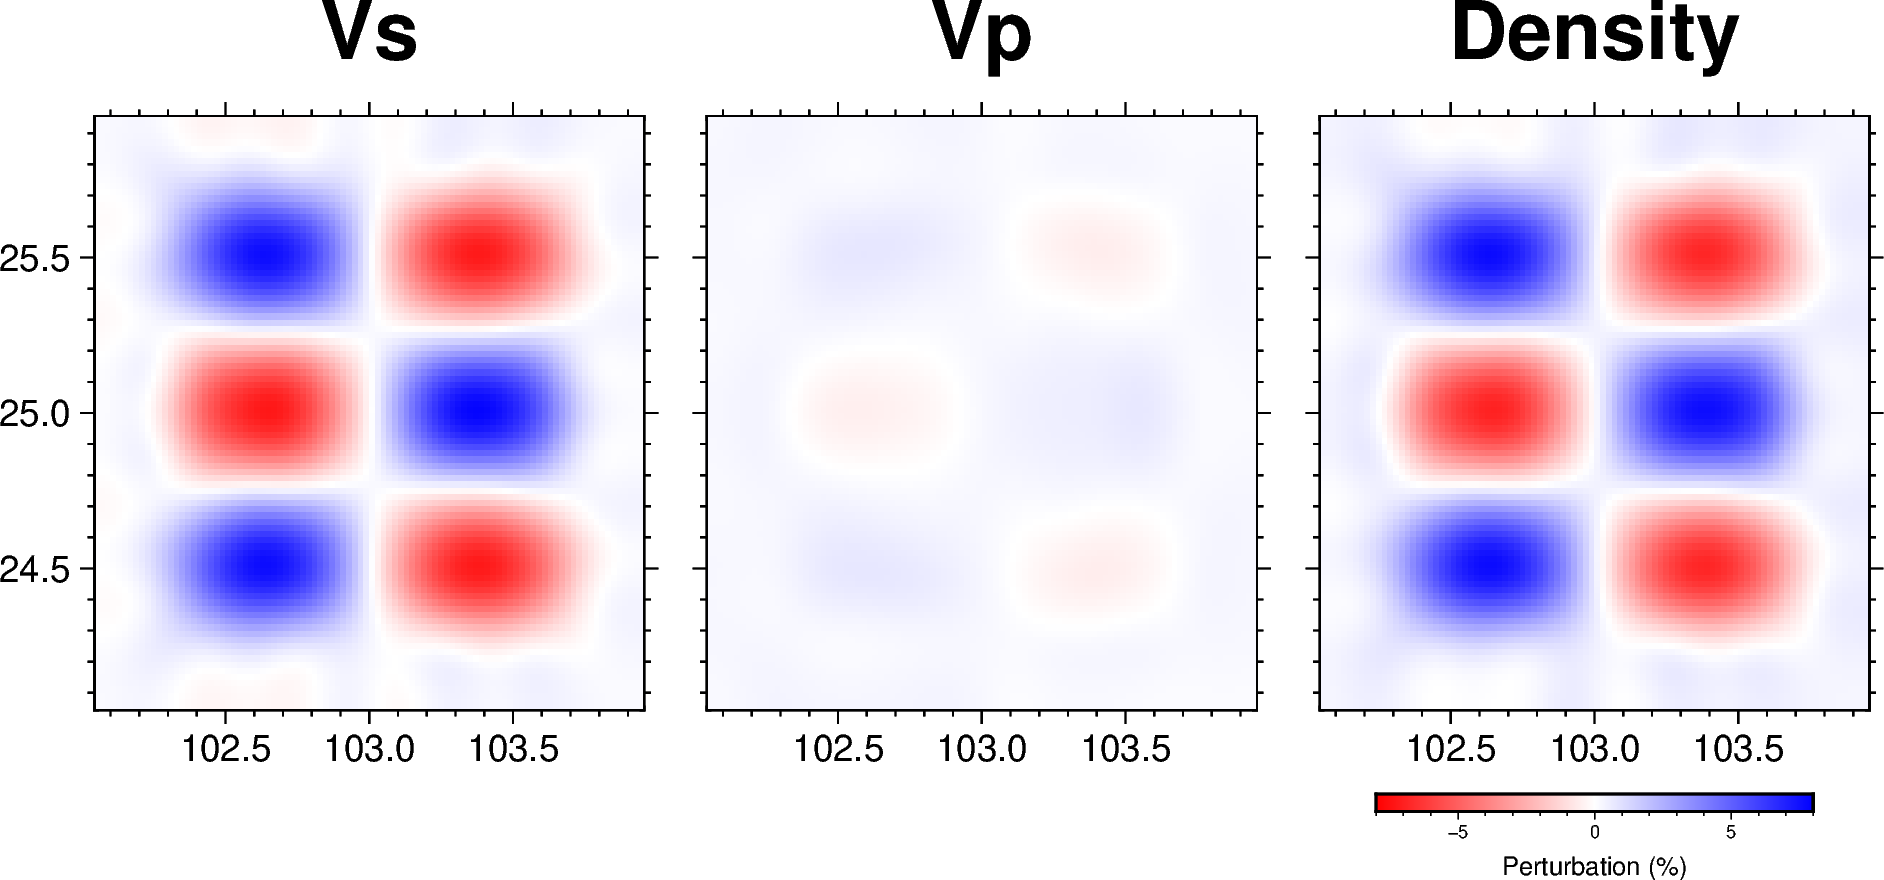

In [36]:

# 深度切片 1.5 km
depth = 3.5
iz = np.argmin(np.abs(z - depth))
print(f"Plotting depth slice at z={z[iz]:.2f} km (index {iz})")

# dv shape: (nx, ny, nz), depth slice -> (nx, ny)
slice2d = dvs[:, :, iz]

xx, yy = np.meshgrid(x, y)  # xx, yy shape: (ny, nx)
# flatten in same order as meshgrid
x_flat = xx.flatten()
y_flat = yy.flatten()
dvs_flat = dvs[:, :, iz].T.flatten()  # transpose to (ny, nx) then flatten
dvp_flat = dvp[:, :, iz].T.flatten()
drho_flat = drho[:, :, iz].T.flatten()
data = [dvs_flat, dvp_flat, drho_flat]
titles = [f"Vs", f"Vp", f"Density"]

fig = pygmt.Figure()
region = [x.min(), x.max(), y.min(), y.max()]
spacing = [x[1] - x[0], y[1] - y[0]]

with fig.subplot(region=region, nrows=1, ncols=3, figsize=(15, 5), sharex="b", sharey="l"):
    pygmt.makecpt(cmap="polar", series=[-vmax, vmax], reverse=True)
    for i, d in enumerate(data):
        fig.basemap(region=region, projection="X?", frame=[f"+t{titles[i]}", "xaf", "yaf"], panel=i)
        grid = pygmt.xyz2grd(
            x=x_flat, y=y_flat, z=d,
            region=region,
            spacing=spacing
        )
        fig.grdimage(grid=grid, cmap=True)
    fig.colorbar(frame=["x+lPerturbation (%)"])

fig.show()


Plotting cross-section at y=24.9900 (index 47)


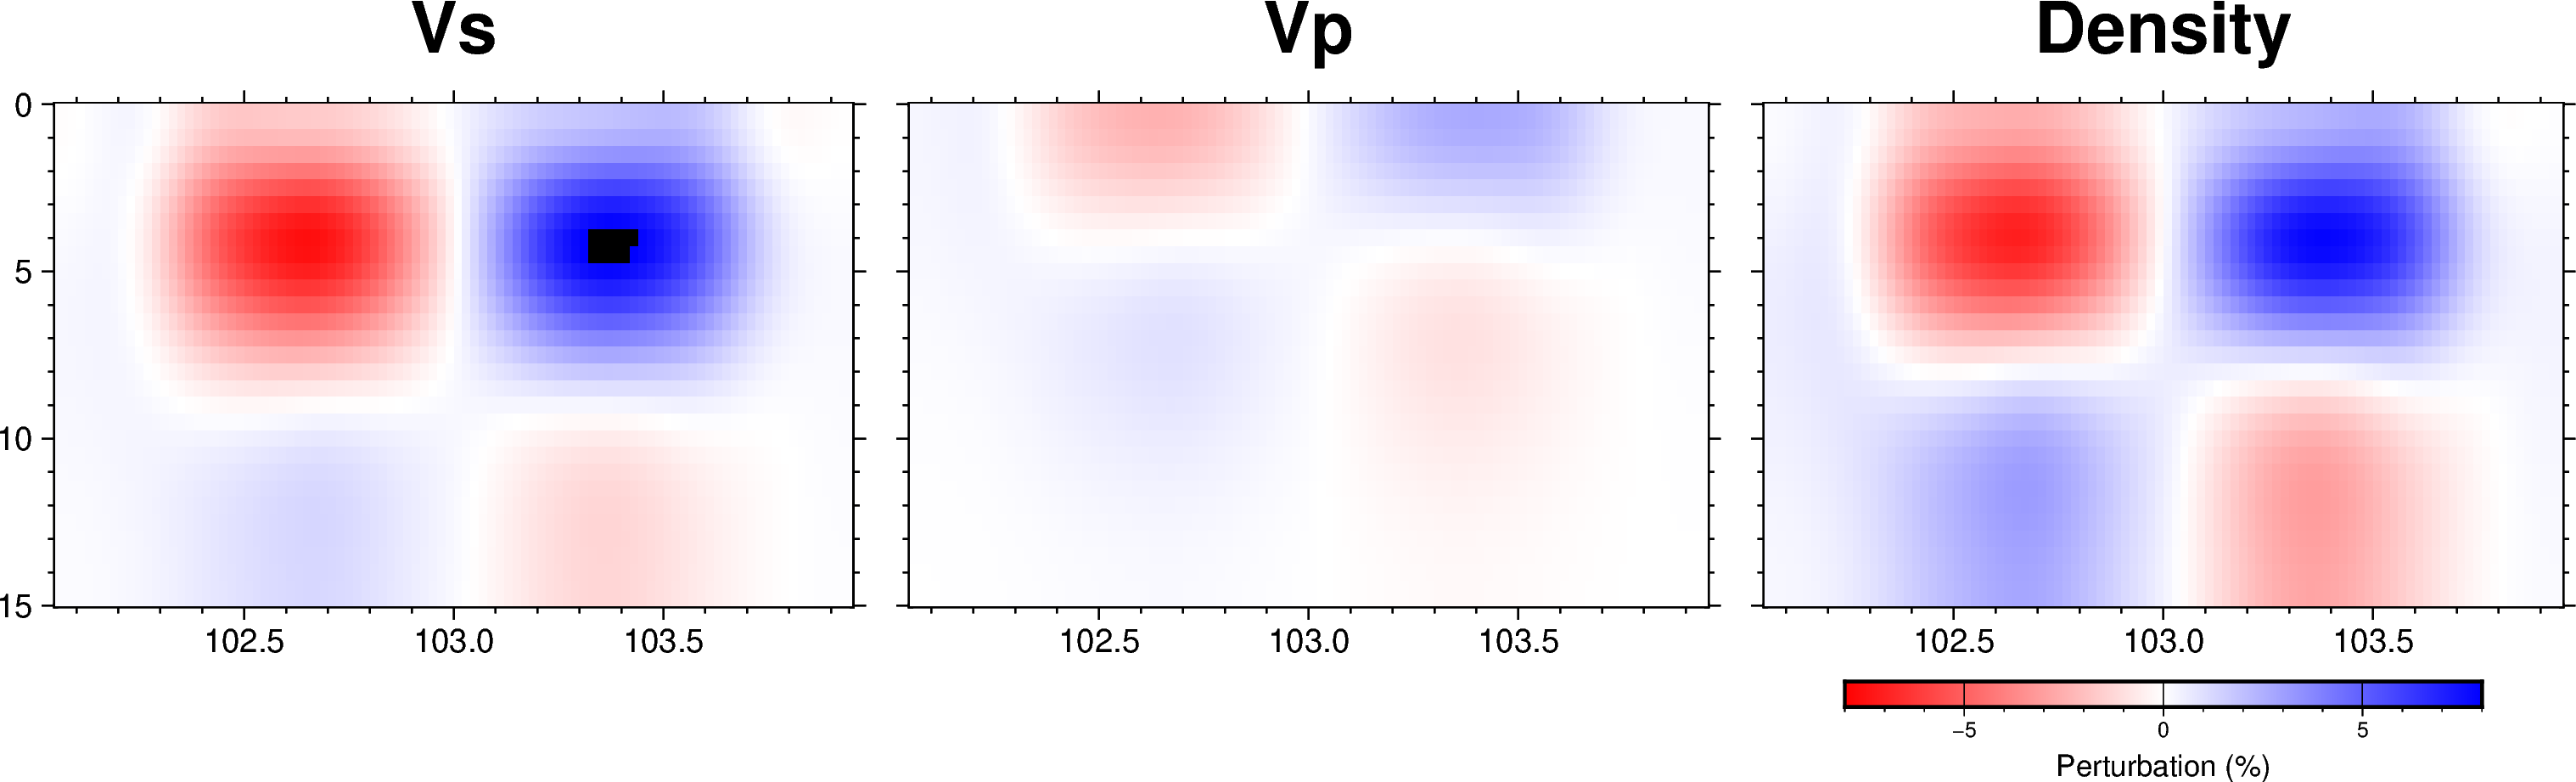

In [38]:

# Cross-section at y=25
lat = 25.0
iy = np.argmin(np.abs(y - lat))
print(f"Plotting cross-section at y={y[iy]:.4f} (index {iy})")

# dv shape: (nx, ny, nz), cross-section -> (nx, nz)
slice_dvs = dvs[:, iy, :]
slice_dvp = dvp[:, iy, :]
slice_drho = drho[:, iy, :]
data = [slice_dvs, slice_dvp, slice_drho]
labels = ["Vs anomaly (%)", "Vp anomaly (%)", "Density anomaly (%)"]

xx, zz = np.meshgrid(x, z)  # shape (nz, nx)
x_flat = xx.flatten()
z_flat = zz.flatten()

fig = pygmt.Figure()
# Use normal region ordering for GMT; negative projection height flips depth axis
region = [x.min(), x.max(), z.min(), z.max()]
spacing = [x[1] - x[0], z[1] - z[0]]

with fig.subplot(region=region, nrows=1, ncols=3, figsize=(25, 5), sharex="b", sharey="l"):
    pygmt.makecpt(cmap="polar", series=[-vmax, vmax], reverse=True)
    for i, d in enumerate(data):
        v_flat = d.T.flatten()  # transpose to (nz, nx) then flatten
        grid = pygmt.xyz2grd(
            x=x_flat, y=z_flat, z=v_flat,
            region=region,
            spacing=spacing
        )
        fig.basemap(region=region, projection="X?/-?", frame=[f"+t{titles[i]}", "xaf", "yaf"], panel=i)
        fig.grdimage(grid=grid, cmap=True)
# fig.colorbar(frame=["x+lAnomaly", "y+l%"])
    fig.colorbar(frame=['afg', 'x+lPerturbation (%)'])

fig.show()
